# Papers about Artificial Intelligence on OpenAlex

**DATASCI 530 - Assignment 3**\
**Author:** Xueqian Cheng

## Summary of findings

Using the OpenAlex Works API, I analyzed academic works with the phrase "artificial intelligence" (AI) in their titles.

- **Size:** OpenAlex lists about 334,000 works with "artificial intelligence" in the title.
- **Countries:** Since 2000, authors based in the United States (37,000 works), China (30,000) and India (25,000) have produced the most AI works, followed by the United Kingdom and Indonesia.
- **Most-cited papers:** The 10 most-cited AI papers since 2000 were mostly published in 2017-2020 and focus on AI in medicine and healthcare, explainable AI, and education. The top paper, on AI in medicine (Topol, 2018), has over 10,000 citations.
- **Trends:** AI publishing has grown rapidly, from about 300 works in 2000 to 77,000 in 2025. "Machine learning" appears in even more titles than "artificial intelligence" (105,000 in 2025). "LLM" barely appeared before 2023 but reached about 28,000 titles in 2025, following the release of ChatGPT.
- **New insight:** AI research has become much more openly available. The share of AI works that are open access rose from 10% in 2000 to 67% in 2025, passing 50% for the first time in 2020.

---
## 0. Setup

All data comes from the [OpenAlex Works API](https://docs.openalex.org/api-entities/works).
Every request is a URL; the API answers with JSON, which Python turns into a dictionary.

In [ ]:
# Packages
import requests      
import json          
import jmespath      
import pandas as pd  
import matplotlib.pyplot as plt

# Base address of the OpenAlex Works API.
# Every query is this URL plus "?filter=...". Filters are separated by commas.
url_base = "https://api.openalex.org/works"


In [2]:
def get_openalex(query):
    """Request url_base + query from OpenAlex and return the JSON as a dictionary."""
    return requests.get(url_base + query).json()

### 0.1 What does a response look like?

In [ ]:
example = get_openalex('?filter=title.search:"artificial intelligence"&per_page=1')

print(example.keys())
print(example["meta"])
print(example["results"][0].keys())   # all the fields available for one work

# Save a nicely indented copy to browse in VS Code
import os
os.makedirs("json_files", exist_ok=True)
with open("json_files/example_response.json", "w") as file:
    file.write(json.dumps(example, indent=4))


dict_keys(['meta', 'results', 'group_by'])
{'count': 333848, 'db_response_time_ms': 20, 'page': 1, 'per_page': 1, 'groups_count': None, 'x_query': {'oql': 'works where title has (stemmed "artificial intelligence")', 'oqo': {'get_rows': 'works', 'filter_rows': [{'column_id': 'display_name.search', 'value': '"artificial intelligence"', 'operator': 'has'}]}, 'url': '/works?filter=display_name.search:%22artificial intelligence%22&per_page=1'}, 'cost_usd': 0.001}
dict_keys(['id', 'doi', 'title', 'display_name', 'relevance_score', 'publication_year', 'publication_date', 'ids', 'language', 'primary_location', 'type', 'indexed_in', 'open_access', 'authorships', 'institutions', 'countries_distinct_count', 'institutions_distinct_count', 'corresponding_author_ids', 'corresponding_institution_ids', 'apc_list', 'apc_paid', 'fwci', 'has_fulltext', 'cited_by_count', 'citation_normalized_percentile', 'cited_by_percentile_year', 'biblio', 'is_retracted', 'is_paratext', 'is_xpac', 'primary_topic', 'topi

---
## 1. How many works have "artificial intelligence" in their titles?

In [4]:
q1 = get_openalex('?filter=title.search:"artificial intelligence"&per_page=1')
n_ai_works = q1["meta"]["count"]

print(f"Works with 'artificial intelligence' in the title: {n_ai_works:,}")


Works with 'artificial intelligence' in the title: 333,848


Without any filter, there are over 300 thousands academic pieces about AI in the world.

---
## 2. AI publications by country since 2000


In [11]:
# request the grouped counts, build a DataFrame, rename and sort columns, show the top 15
q2 = get_openalex('?filter=title.search:"artificial intelligence",publication_year:>1999'
                  '&group_by=authorships.countries')

countries = pd.DataFrame(q2["group_by"])

countries = (pd.DataFrame(q2["group_by"])
             .rename(columns={"key_display_name": "Country", "count": "AI publications"})
             [["Country", "AI publications"]]
             .sort_values("AI publications", ascending=False)
             .reset_index(drop=True))

countries.index = countries.index + 1   # rank starts at 1 instead of 0
countries.head(15)

,Country,AI publications
1,United States,37241
2,China,30124
3,India,25011
4,United Kingdom,12734
5,Indonesia,9434
6,Italy,7470
7,Germany,6925
8,Turkey,6718
9,Russia,5968
10,Canada,5915


---
## 3. The 10 most-cited AI papers since 2000


In [ ]:
q3 = get_openalex('?filter=title.search:"artificial intelligence",publication_year:>1999'
                  '&sort=cited_by_count:desc&per_page=10')

# Authors: one list of names per paper
authors_raw = jmespath.search('results[*].authorships[*].author.display_name', q3)
authors = [", ".join(names) for names in authors_raw]

# Institutions: one list per author per paper -> flatten, remove duplicates, join
insts_raw = jmespath.search('results[*].authorships[*].institutions[*].display_name', q3)
institutions = []
for paper in insts_raw:
    flat = [inst for author in paper for inst in author]   # flatten the authors' lists
    flat = list(dict.fromkeys(flat))                       # remove duplicates
    institutions.append("; ".join(flat) if flat else "Not listed")

# What are the titles of the 10 most highly cited papers on artificial intelligence since 2000?
top10 = pd.DataFrame({
    "Title":        jmespath.search('results[*].title', q3),
    "Year":         jmespath.search('results[*].publication_year', q3),
    "Citations":    jmespath.search('results[*].cited_by_count', q3),
    "Authors":      authors,
    "Institutions": institutions,
})

top10.index = top10.index + 1
top10


,Title,Year,Citations,Authors,Institutions
1,High-performance medicine: the convergence of ...,2018,10279,Eric J. Topol,Scripps Research Institute
2,Explainable Artificial Intelligence (XAI): Con...,2019,10137,"Alejandro Barredo Arrieta, Natalia Díaz-Rodríg...",Tecnalia; Institut national de recherche en sc...
3,Systematic review of research on artificial in...,2019,6847,"Olaf Zawacki‐Richter, Victoria I. Marín, Melis...",Carl von Ossietzky Universität Oldenburg
4,Peeking Inside the Black-Box: A Survey on Expl...,2018,6290,"Amina Adadi, Mohammed Berrada",Sidi Mohamed Ben Abdellah University
5,Proceedings of the 19th International Joint Co...,2005,5781,"Josep M. Pujol, Jordi Delgado, Ramón Sangüesa,...",Not listed
6,Explanation in artificial intelligence: Insigh...,2018,5266,Tim Miller,The University of Melbourne
7,"Artificial intelligence in healthcare: past, p...",2017,4901,"Fei Jiang, Yong Jiang, Hui Zhi, Yi Dong, Hao L...",University of Hong Kong; Capital Medical Unive...
8,Artificial Intelligence (AI): Multidisciplinar...,2019,4526,"Yogesh Kumar Dwivedi, Laurie Hughes, Elvira Is...",Prin. L. N. Welingkar Institute of Management ...
9,"BNAI, NO-TOKEN, and MIND-UNITY: Pillars of a S...",2022,4271,"Wei, Jason, Wang, Xuezhi, Dale Schuurmans, Maa...",Google (United States)
10,Artificial Intelligence in Education: A Review,2020,3983,"Lijia Chen, Pingping Chen, Zhijian Lin",Yango University; Fuzhou University


---
## 4. Year-to-year trends: "artificial intelligence" vs "LLM" vs "GPT" vs "machine learning"

In [26]:
terms = ['"artificial intelligence"', "LLM", "GPT", '"machine learning"']

# For each term, store {year: number of works}
counts = {}
for term in terms:
    response = get_openalex("?filter=title.search:" + term + ",publication_year:2000-2025"
                            "&group_by=publication_year")
    counts[term.strip('"')] = {int(g["key"]): g["count"] for g in response["group_by"]}

# One row per year, one column per keyword.
# Years with no matches are missing from the API response, so fill them with 0.
trends_wide = pd.DataFrame(counts).sort_index().fillna(0).astype(int)
trends_wide.tail()


,artificial intelligence,LLM,GPT,machine learning
2021,16496,36,127,40545
2022,19782,77,218,48148
2023,30880,1719,1804,62445
2024,48909,10624,2640,79151
2025,77047,28175,2586,105023


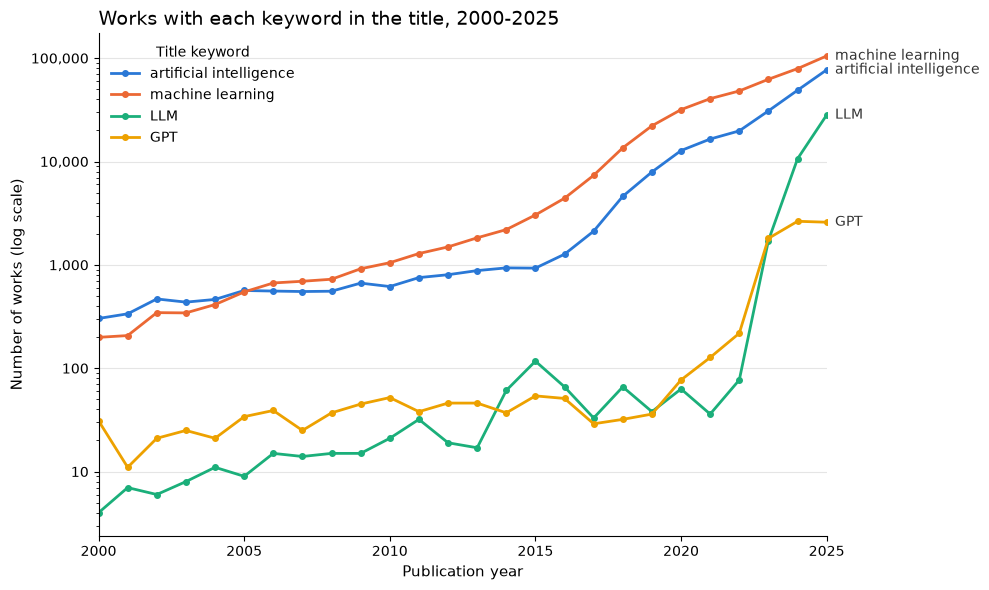

In [ ]:
# One fixed color per keyword
colors = {"artificial intelligence": "#2a78d6",
          "machine learning":        "#eb6834",
          "LLM":                     "#1baf7a",
          "GPT":                     "#eda100"}

fig, ax = plt.subplots(figsize=(10, 6))

for keyword, color in colors.items():
    # Log scale cannot show 0, so years with no matches are left out of the line
    series = trends_wide[keyword].replace(0, float("nan"))
    ax.plot(series.index, series, color=color, linewidth=2,
            marker="o", markersize=4, label=keyword)
    ax.annotate(keyword, xy=(2025, series[2025]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=10, color="#333333")

ax.set_yscale("log")
ax.set_title("Works with each keyword in the title, 2000-2025", fontsize=14, loc="left")
ax.set_xlabel("Publication year", fontsize=11)
ax.set_ylabel("Number of works (log scale)", fontsize=11)
ax.set_xlim(2000, 2025)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Title keyword", frameon=False, loc="upper left")

plt.tight_layout()
plt.show()


---
## 5. New insight: Has AI research become more open access?

Open-access (OA) papers can be read by anyone for free, while closed papers require readers to pay.
Here I check whether AI research has become more openly available since 2000.

Method: OpenAlex marks each work with `open_access.is_oa` (true/false). For each of the two
values I request the number of AI works per year, then compute the OA share = OA works / all works in that year.


In [28]:
# For each open-access status, store {year: number of AI works}
oa_counts = {}
for is_oa in ["true", "false"]:
    response = get_openalex('?filter=title.search:"artificial intelligence",publication_year:2000-2025,'
                            'open_access.is_oa:' + is_oa + '&group_by=publication_year')
    oa_counts[is_oa] = {int(g["key"]): g["count"] for g in response["group_by"]}

# One row per year: number of open and closed works, total, and the open-access share
oa = (pd.DataFrame(oa_counts).sort_index().fillna(0).astype(int)
        .rename(columns={"true": "Open access", "false": "Closed"}))
oa["Total"] = oa["Open access"] + oa["Closed"]
oa["OA share (%)"] = (100 * oa["Open access"] / oa["Total"]).round(1)

oa.loc[[2000, 2005, 2010, 2015, 2020, 2025]]


,Open access,Closed,Total,OA share (%)
2000,30,273,303,9.9
2005,70,495,565,12.4
2010,125,492,617,20.3
2015,315,615,930,33.9
2020,6491,6269,12760,50.9
2025,51686,25361,77047,67.1


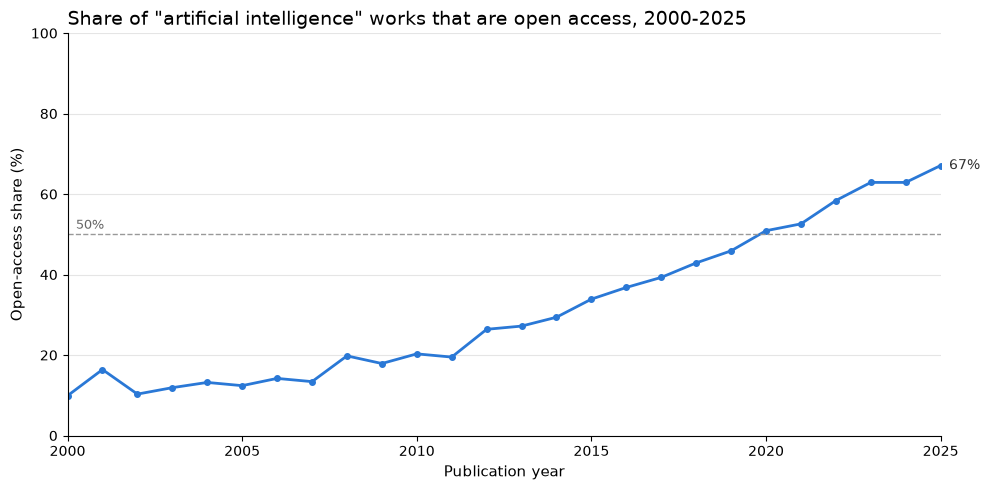

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(oa.index, oa["OA share (%)"], color="#2a78d6", linewidth=2, marker="o", markersize=4)
ax.axhline(50, color="#999999", linewidth=1, linestyle="--")
ax.annotate("50%", xy=(2000, 50), xytext=(6, 4), textcoords="offset points",
            fontsize=9, color="#666666")
ax.annotate(f'{oa.loc[2025, "OA share (%)"]:.0f}%', xy=(2025, oa.loc[2025, "OA share (%)"]),
            xytext=(6, 0), textcoords="offset points", va="center", fontsize=10, color="#333333")

ax.set_title('Share of "artificial intelligence" works that are open access, 2000-2025',
             fontsize=14, loc="left")
ax.set_xlabel("Publication year", fontsize=11)
ax.set_ylabel("Open-access share (%)", fontsize=11)
ax.set_xlim(2000, 2025)
ax.set_ylim(0, 100)
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


## 6. What do we learn?

The share of "artificial intelligence" works that are open access rose from about 10% in 2000 to 67% in 2025. Growth was slow before 2010 but has been steady since then, and 2020 was the first year in which more than half of AI works were openly available. This shift likely reflects funder open-access mandates, the growth of open-access journals, and the popularity of preprint servers such as arXiv. As a result, most new AI research is now free for anyone to read, including researchers at institutions without expensive journal subscriptions.